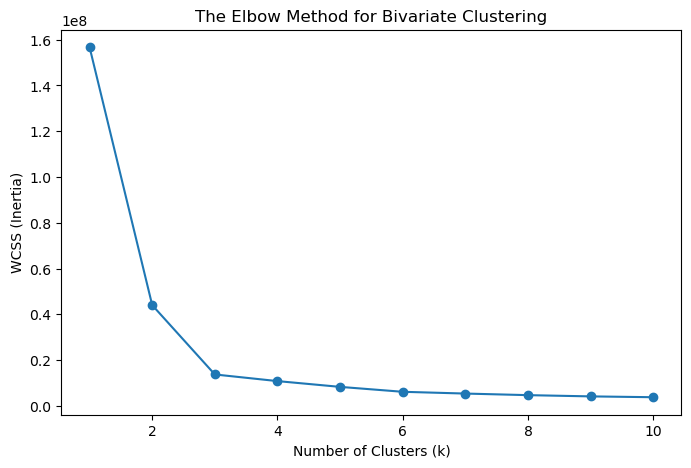

Optimal number of clusters (bivariate): 3


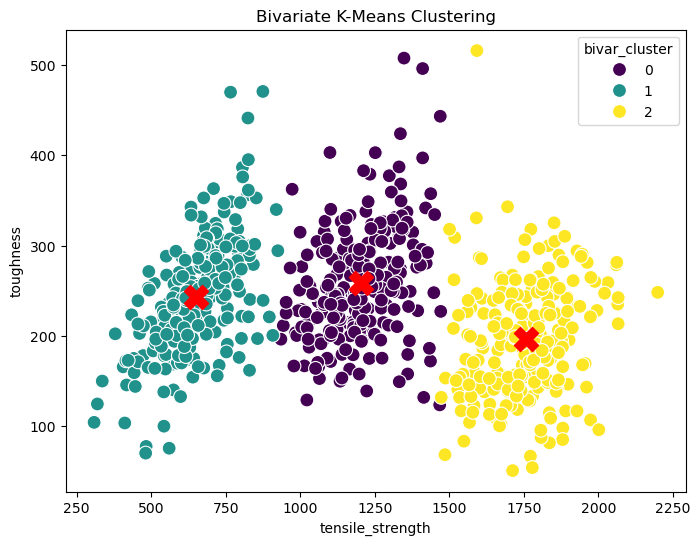

Bivariate Cluster Interpretation (Means):
               tensile_strength   toughness
bivar_cluster                              
0                   1204.422331  258.900169
1                    649.284894  242.753234
2                   1757.423319  196.448210


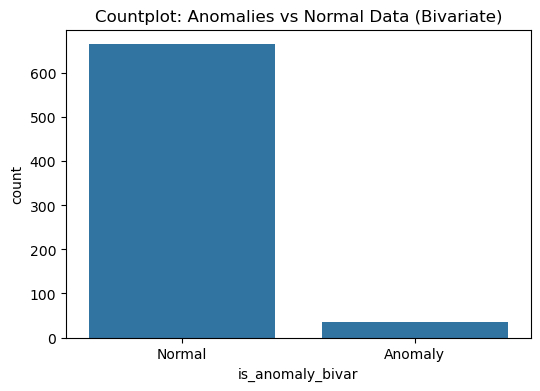

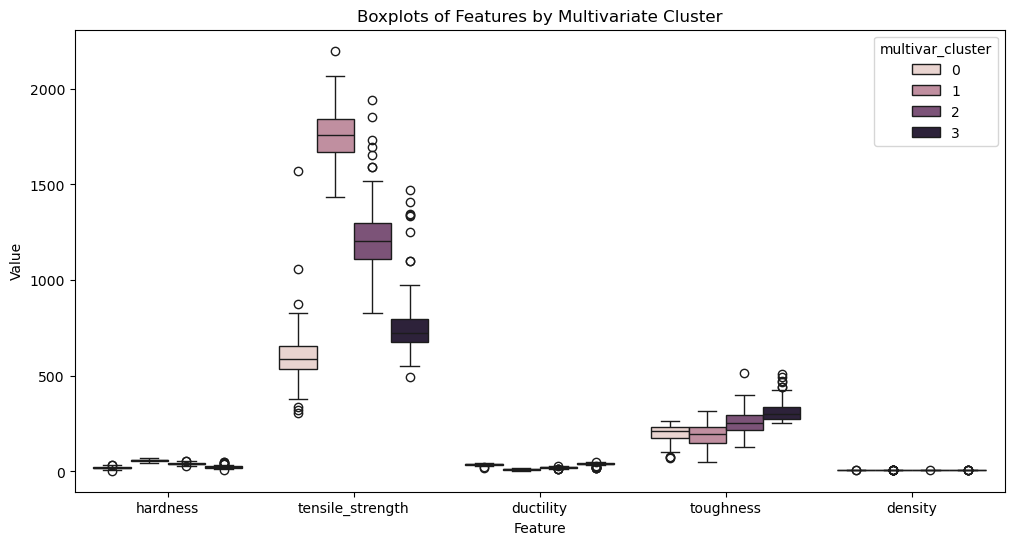


Multivariate Cluster Interpretation (Mean Values):
    hardness  tensile_strength  ductility   toughness   density
0  20.579635        600.220511  36.268759  201.829270  7.939343
1  58.267523       1757.381802  10.977883  190.889414  8.436306
2  41.596975       1209.422479  20.895798  255.994244  8.247563
3  24.528350        767.612039  38.201942  312.421359  7.995437


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ensure the metal_data.csv file is in the same directory as your notebook.

# --- Part a) Import data and determine the optimal number of bivariate clusters ---
mData = pd.read_csv('metal_data.csv') 

# Select the bivariate data for clustering
X_bivar = mData[['tensile_strength', 'toughness']].values

# Use the Elbow Method to find the optimal number of clusters
wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0, n_init=10)
    kmeans.fit(X_bivar)
    wcss.append(kmeans.inertia_) 

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method for Bivariate Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

# Based on visual inspection of the elbow plot, assume the optimal number is 3
optimal_clusters_bivar = 3 
print(f"Optimal number of clusters (bivariate): {optimal_clusters_bivar}")

# --- Part b) Interpret the clusters and visualize the cluster in the data ---
# Fit KMeans with the optimal number of clusters
kmeans_bivar = KMeans(n_clusters=optimal_clusters_bivar, init='k-means++', random_state=0, n_init=10)
y_kmeans_bivar = kmeans_bivar.fit_predict(X_bivar)
mData['bivar_cluster'] = y_kmeans_bivar

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='tensile_strength', y='toughness', hue='bivar_cluster', data=mData, palette='viridis', s=100)
plt.scatter(kmeans_bivar.cluster_centers_[:, 0], kmeans_bivar.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Bivariate K-Means Clustering')
plt.show()

# Interpret clusters based on average values
print("Bivariate Cluster Interpretation (Means):")
print(mData.groupby('bivar_cluster')[['tensile_strength', 'toughness']].mean())

# --- Part c) Countplot of Anomalies vs Normal Data ---
# Identify anomalies as data points far from their cluster centroid
distances = kmeans_bivar.transform(X_bivar)
min_distances = distances[np.arange(len(distances)), y_kmeans_bivar]
threshold = np.percentile(min_distances, 95) 
mData['is_anomaly_bivar'] = min_distances > threshold

# Plot results
plt.figure(figsize=(6, 4))
sns.countplot(x='is_anomaly_bivar', data=mData)
plt.title('Countplot: Anomalies vs Normal Data (Bivariate)')
plt.xticks([0, 1], ['Normal', 'Anomaly'])
plt.show()

# --- Part d) Multivariate clustering and visualization ---
features = ['hardness', 'tensile_strength', 'ductility', 'toughness', 'density']
X_multivar = mData[features].values

# Scale features for accurate clustering
scaler = StandardScaler()
X_multivar_scaled = scaler.fit_transform(X_multivar)

# Fit KMeans++ (assuming k=4 based on hypothetical elbow plot)
kmeans_multivar = KMeans(n_clusters=4, init='k-means++', random_state=0, n_init=10)
y_kmeans_multivar = kmeans_multivar.fit_predict(X_multivar_scaled)
mData['multivar_cluster'] = y_kmeans_multivar

# Plot boxplots of all features
mData_melted = mData.melt(id_vars=['multivar_cluster'], value_vars=features, var_name='Feature', value_name='Value')
plt.figure(figsize=(12, 6))
sns.boxplot(x='Feature', y='Value', hue='multivar_cluster', data=mData_melted)
plt.title('Boxplots of Features by Multivariate Cluster')
plt.show()

# Mean values of features, grouped by cluster
cluster_centers_unscaled = scaler.inverse_transform(kmeans_multivar.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_unscaled, columns=features)
print("\nMultivariate Cluster Interpretation (Mean Values):")
print(centers_df)
